# Cargar el dataset y preparar las variables para el árbol de decisión

En este paso se carga `dataset_final.csv`, se toman solo las columnas de **energía** y **periodicidad**, y se separa la etiqueta objetivo (`etiqueta`) para entrenar el clasificador.


In [1]:
import pandas as pd

# Ruta del archivo
csv_path = "dataset_energia_periodicidad.csv"

# Cargar dataset
df = pd.read_csv(csv_path)

# Buscar nombres posibles de columnas por si cambian un poco
energy_candidates = ["energia", "energía", "Energy", "energy"]
periodicity_candidates = ["periodicidad", "periodicity", "Periodicidad"]
target_candidates = ["etiqueta", "[etiqueta]", "label", "target"]

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"No se encontró ninguna de estas columnas: {candidates}. Columnas disponibles: {list(df.columns)}")

energy_col = find_column(df, energy_candidates)
periodicity_col = find_column(df, periodicity_candidates)
target_col = find_column(df, target_candidates)

# Tomar solo las columnas necesarias y quitar filas incompletas
df_model = df[[energy_col, periodicity_col, target_col]].dropna().copy()

# Variables de entrada y salida
X = df_model[[energy_col, periodicity_col]]
y = df_model[target_col]

print("Columnas usadas:")
print(f"  Energía:      {energy_col}")
print(f"  Periodicidad: {periodicity_col}")
print(f"  Target:       {target_col}")

print("\nTamaño del dataset limpio:")
print(df_model.shape)

print("\nPrimeras filas:")
display(df_model.head())

Columnas usadas:
  Energía:      energia
  Periodicidad: periodicidad
  Target:       etiqueta

Tamaño del dataset limpio:
(254, 3)

Primeras filas:


,energia,periodicidad,etiqueta
0,0.004790,0.9513,silence
1,0.021715,0.3324,unvoice
2,0.150816,0.3476,voice
3,0.033516,0.3857,unvoice
4,0.000669,0.1082,silence


## Separación de datos y entrenamiento del árbol de decisión

En esta etapa se divide el dataset en entrenamiento y prueba, se entrena un árbol de decisión usando solo energía y periodicidad, y luego se evalúa su desempeño.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Crear y entrenar el árbol de decisión
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Evaluación del modelo

Aquí se calculan las predicciones sobre el conjunto de prueba y se muestran métricas básicas de clasificación.

In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicción
y_pred = tree_model.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7843

Reporte de clasificación:
              precision    recall  f1-score   support

     silence       0.69      0.86      0.77        21
     unvoice       0.80      0.60      0.69        20
       voice       1.00      1.00      1.00        10

    accuracy                           0.78        51
   macro avg       0.83      0.82      0.82        51
weighted avg       0.79      0.78      0.78        51

Matriz de confusión:
[[18  3  0]
 [ 8 12  0]
 [ 0  0 10]]


## Visualización del árbol y guardado del modelo

Se puede ver la estructura del árbol y guardar el modelo entrenado para reutilizarlo después.

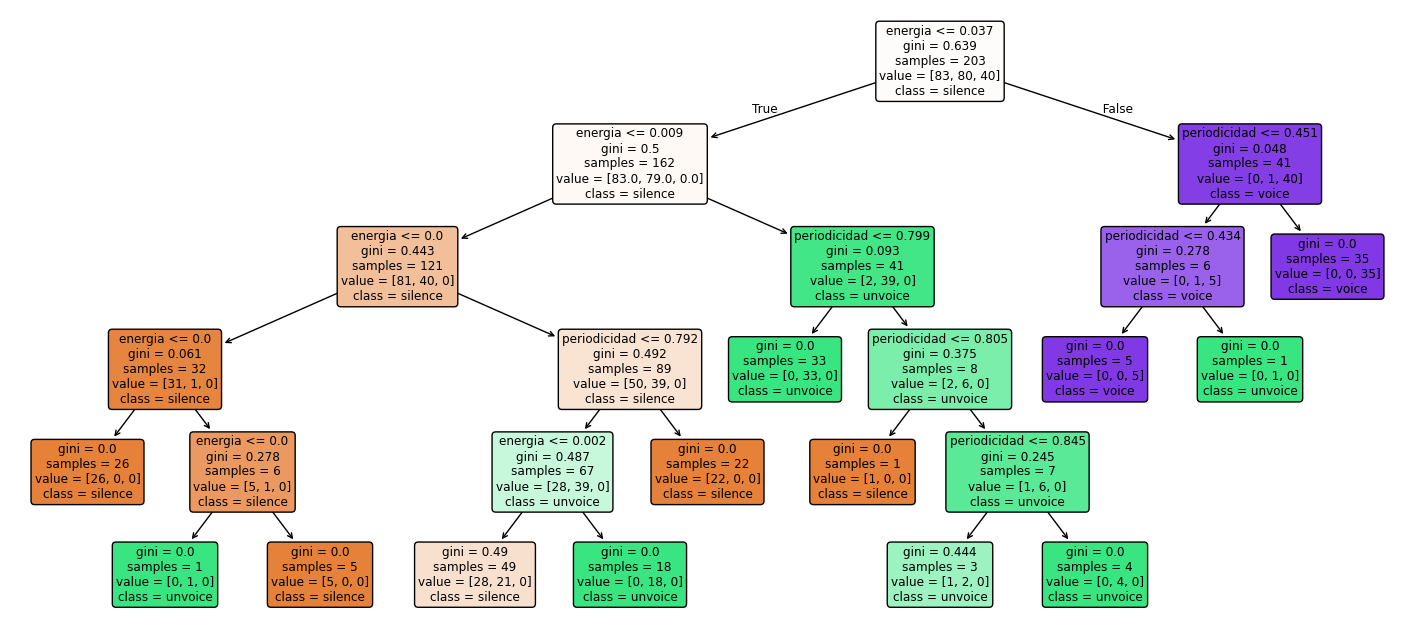

Modelo guardado como decision_tree_voice_unvoice_silence.pkl


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import joblib

plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=[str(c) for c in tree_model.classes_],
    filled=True,
    rounded=True
)
plt.show()

# Guardar el modelo
joblib.dump(tree_model, "decision_tree_voice_unvoice_silence.pkl")
print("Modelo guardado como decision_tree_voice_unvoice_silence.pkl")